# BIRCH Clustering Analysis

Balanced Iterative Reducing and Clustering using Hierarchies (BIRCH) for student behavior segmentation.

## Overview
- Load encoded dataset from `encoded_unsupervised.csv`
- Apply BIRCH clustering
- Evaluate clusters using silhouette score and other metrics
- Visualize and interpret clusters

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import Birch
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")


Libraries loaded successfully


## 1. Load Data

Load the preprocessed and scaled dataset.


In [7]:
# Load encoded dataset
DATA_PATH = '../data/final/encoded_unsupervised.csv'
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (32548, 25)
Columns: ['highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'date_registration', 'avg_clicks_per_day', 'module_presentation_length', 'tma_cma_weighted_score', 'total_submissions', 'late_submissions_count', 'avg_submission_delay', 'sites_revisit_ratio', 'activity_diversity_ratio', 'code_module_BBB', 'code_module_CCC', 'code_module_DDD', 'code_module_EEE', 'code_module_FFF', 'code_module_GGG', 'code_presentation_2013J', 'code_presentation_2014B', 'code_presentation_2014J', 'gender_M', 'disability_Y']

First few rows:


,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,date_registration,avg_clicks_per_day,module_presentation_length,tma_cma_weighted_score,total_submissions,...,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013J,code_presentation_2014B,code_presentation_2014J,gender_M,disability_Y
0,0.75,1.000000,1.0,-0.368196,3.0,-1.818699,0.765076,0.909289,0.824,0.000,...,0,0,0,0,0,1,0,0,1,0
1,0.75,0.222222,0.5,-0.368196,0.0,0.333158,0.132223,0.909289,0.654,0.000,...,0,0,0,0,0,1,0,0,0,0
2,0.50,0.333333,0.5,-0.368196,0.0,-0.458563,0.309507,0.909289,0.000,-0.625,...,0,0,0,0,0,1,0,0,0,1
3,0.50,0.555556,0.5,-0.368196,0.0,0.353459,0.105180,0.909289,0.763,0.000,...,0,0,0,0,0,1,0,0,0,0
4,0.25,0.555556,0.0,-0.368196,0.0,-2.163809,-0.147294,0.909289,0.550,0.000,...,0,0,0,0,0,1,0,0,0,0


## 1.1 Feature Engineering & Selection

Create new behavioral features and select final 9 columns for clustering.

In [8]:
from sklearn.preprocessing import StandardScaler

# === Feature Engineering ===
eps = 1e-6  # prevents divide-by-zero

# 1) Late submission ratio (time-management discipline)
df['late_submission_ratio'] = df['late_submissions_count'] / (df['total_submissions'] + eps)

# 2) Procrastination index (severity of late behaviour)
df['procrastination_index'] = (
    df['late_submission_ratio'] * df['avg_submission_delay'].clip(lower=0)
)

# 3) Score per submission (efficiency of attempts)
df['score_per_submission'] = df['tma_cma_weighted_score'] / (df['total_submissions'] + eps)

# 4) Effort-to-score ratio (hard-working vs efficient learners)
df['effort_to_score_ratio'] = df['avg_clicks_per_day'] / (df['tma_cma_weighted_score'] + 1)

print("New features created:")
print(df[['late_submission_ratio', 'procrastination_index', 'score_per_submission', 'effort_to_score_ratio']].describe())

# === Select Final 9 Columns ===
# 5 existing (already scaled) + 4 new (need scaling)
existing_features = [
    'avg_clicks_per_day',
    'activity_diversity_ratio',
    'sites_revisit_ratio',
    'total_submissions',
    'avg_submission_delay'
]

new_features = [
    'late_submission_ratio',
    'procrastination_index',
    'score_per_submission',
    'effort_to_score_ratio'
]

# === Scale New Features Only ===
scaler_new = StandardScaler()
df[new_features] = scaler_new.fit_transform(df[new_features])

print("\nNew features after scaling:")
print(df[new_features].describe())

# === Keep Only Final 9 Columns ===
final_features = existing_features + new_features
df = df[final_features]

print(f"\nFinal dataset shape: {df.shape}")
print(f"Final columns: {df.columns.tolist()}")

New features created:
       late_submission_ratio  procrastination_index  score_per_submission  \
count           3.254800e+04           3.254800e+04          32548.000000   
mean            3.953741e+03           1.915362e+04          47749.266204   
std             2.548643e+05           2.620120e+05         168494.132519   
min            -8.283661e+05          -1.993858e+02             -7.977664   
25%            -8.417284e-01           0.000000e+00             -0.004000   
50%             1.325388e+00           0.000000e+00             -0.000000   
75%             2.390034e+00           0.000000e+00              1.114284   
max             1.584907e+06           3.302955e+07         973000.000000   

       effort_to_score_ratio  
count           32548.000000  
mean               -0.047759  
std                 0.725330  
min                -1.484743  
25%                -0.343565  
50%                 0.000010  
75%                 0.353685  
max                11.718226  

New 

## 2. BIRCH Clustering

BIRCH parameters:
- **threshold**: Maximum radius of a subcluster (controls cluster granularity)
- **branching_factor**: Maximum number of subclusters per node
- **n_clusters**: Final number of clusters


## 2.1 Finding Optimal Number of Clusters

Use Silhouette Score and Elbow Method to determine the best k value.


k=2: Silhouette=0.6936
k=3: Silhouette=0.6695
k=4: Silhouette=0.6698
k=5: Silhouette=0.4681
k=6: Silhouette=0.4464
k=7: Silhouette=0.4693
k=8: Silhouette=0.4546


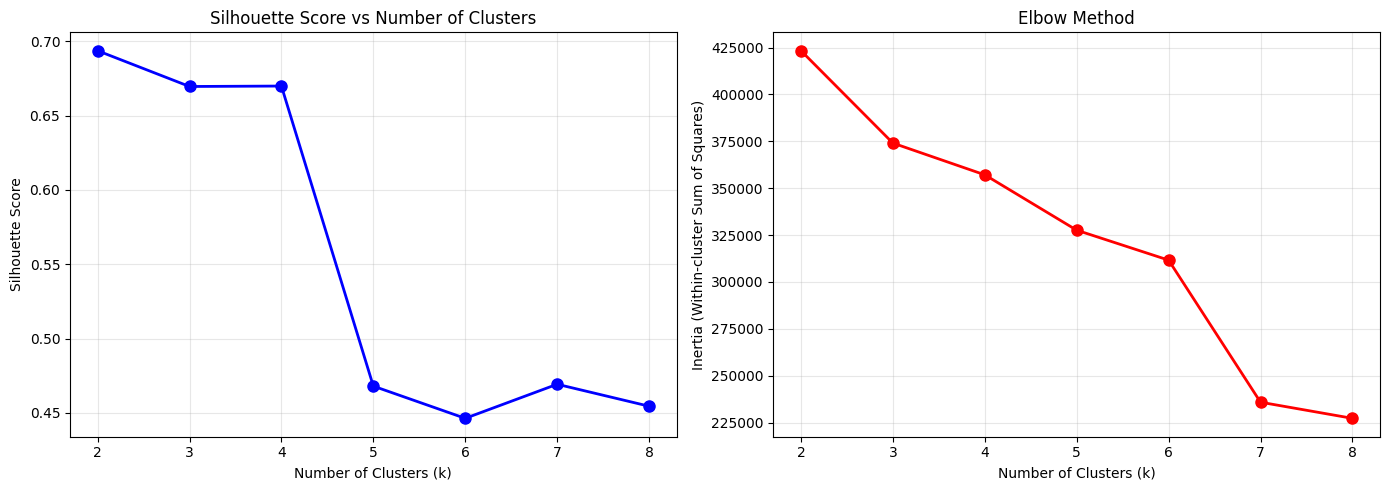

In [9]:
# Test different numbers of clusters
k_range = range(2, 9)
silhouette_scores = []
inertias = []

for k in k_range:
    birch_temp = Birch(threshold=0.5, branching_factor=50, n_clusters=k)
    labels_temp = birch_temp.fit_predict(df)
    
    silhouette_scores.append(silhouette_score(df, labels_temp))
    
    # Calculate inertia (within-cluster sum of squares)
    inertia = 0
    for i in range(k):
        cluster_points = df[labels_temp == i]
        if len(cluster_points) > 0:
            centroid = cluster_points.mean()
            inertia += ((cluster_points - centroid) ** 2).sum().sum()
    inertias.append(inertia)
    
    print(f"k={k}: Silhouette={silhouette_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette Score Plot
axes[0].plot(k_range, silhouette_scores, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score vs Number of Clusters')
axes[0].set_xticks(list(k_range))
axes[0].grid(True, alpha=0.3)

# Elbow Plot
axes[1].plot(k_range, inertias, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Inertia (Within-cluster Sum of Squares)')
axes[1].set_title('Elbow Method')
axes[1].set_xticks(list(k_range))
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.2 Inplementing Clusters by using the specified k

Number of clusters found: 3

Cluster distribution:
cluster
0    28705
1      306
2     3537
Name: count, dtype: int64
PCA explained variance ratio: [0.80735137 0.0685184 ]
Total variance explained: 87.59%


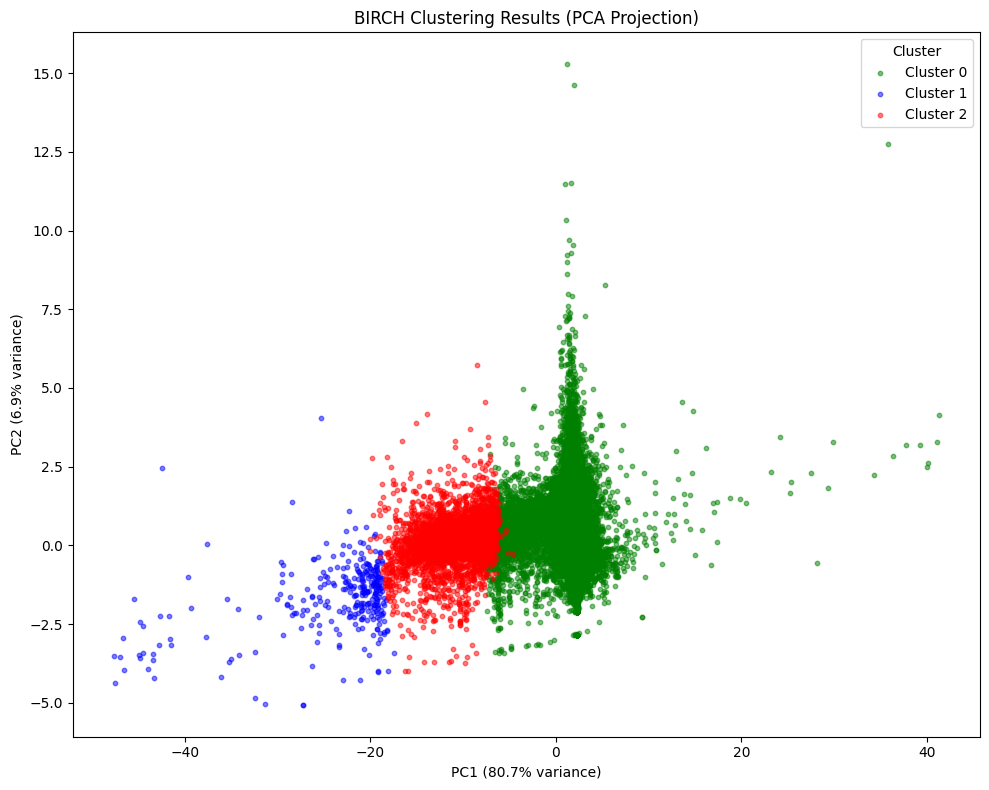

PCA Loadings (Feature Contributions):
                            PC1    PC2
avg_submission_delay      0.995  0.083
effort_to_score_ratio    -0.055  0.590
avg_clicks_per_day       -0.050  0.503
total_submissions        -0.040  0.177
sites_revisit_ratio      -0.029  0.484
activity_diversity_ratio -0.028  0.292
procrastination_index     0.016  0.076
score_per_submission      0.016  0.185
late_submission_ratio     0.012  0.023


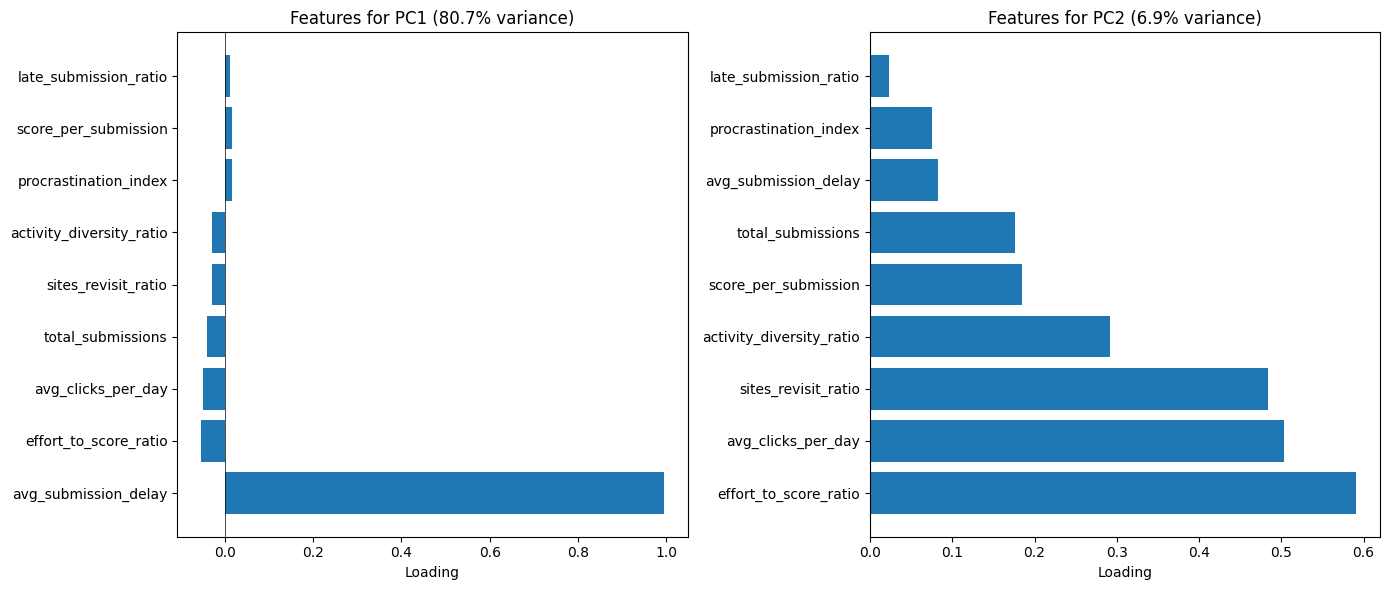

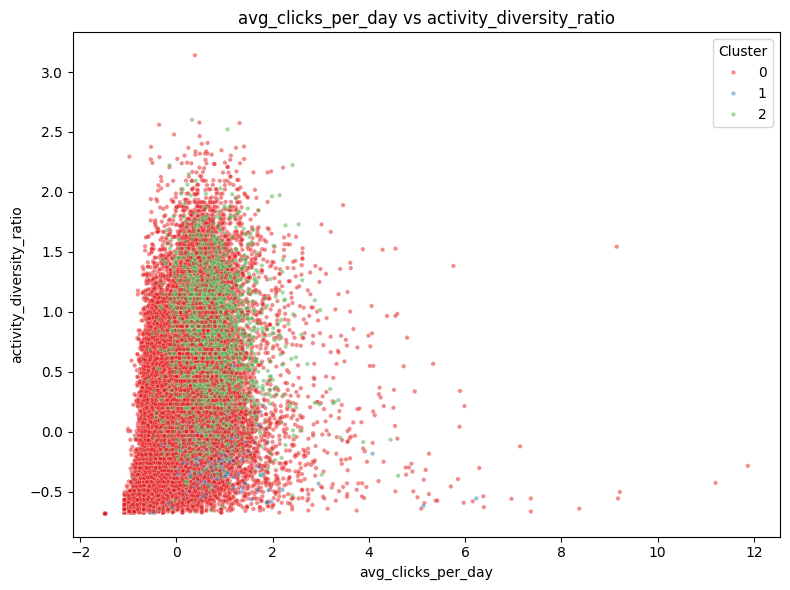

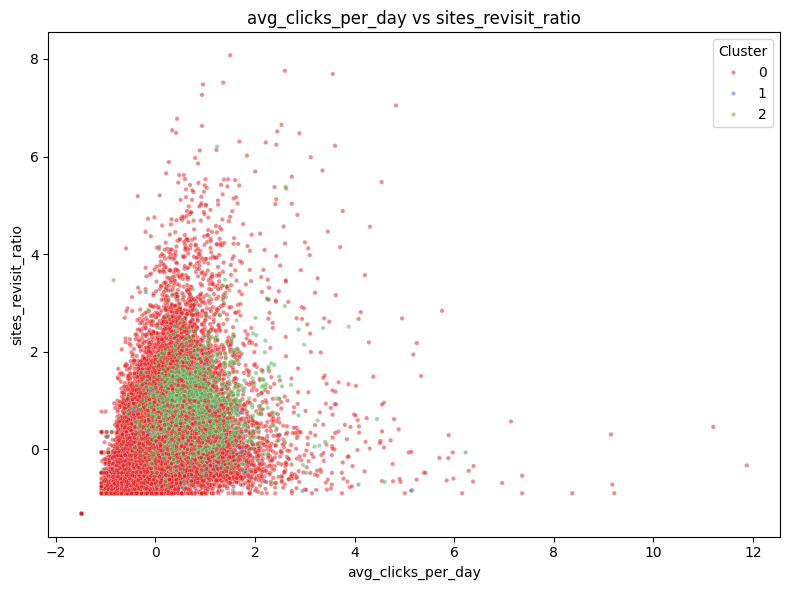

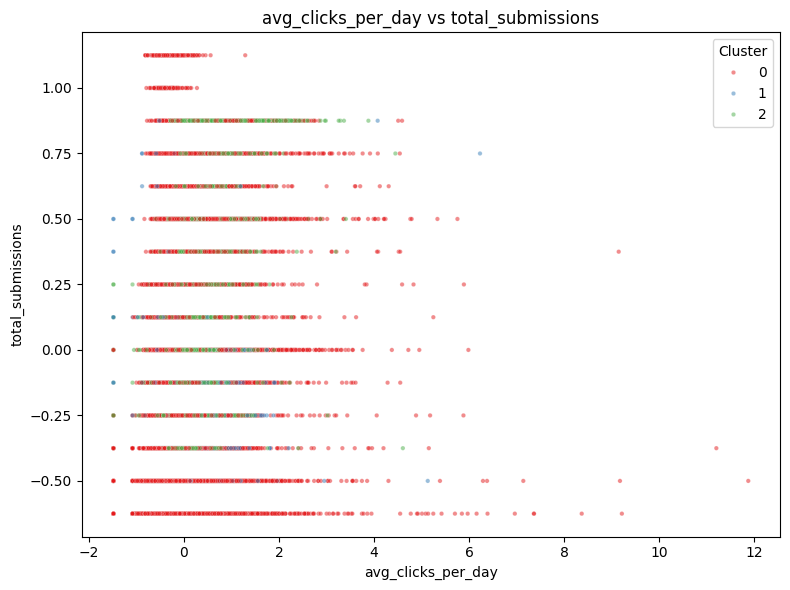

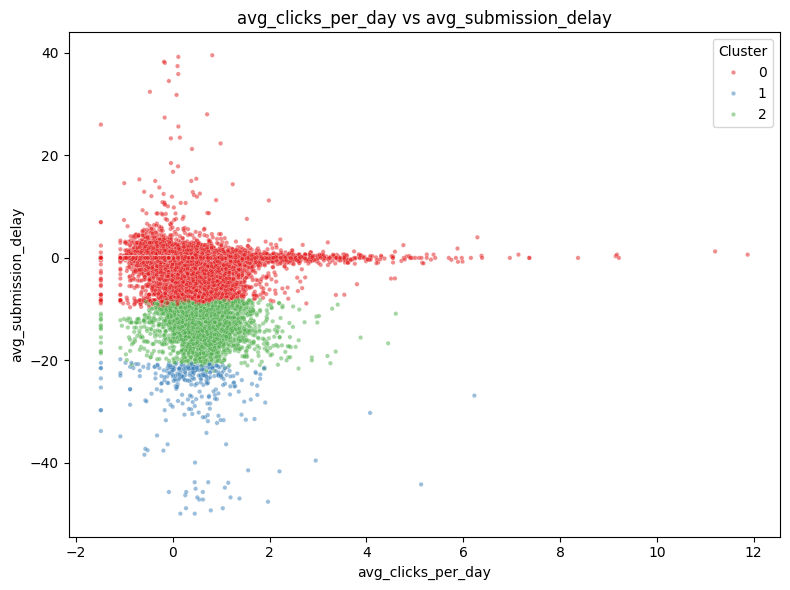

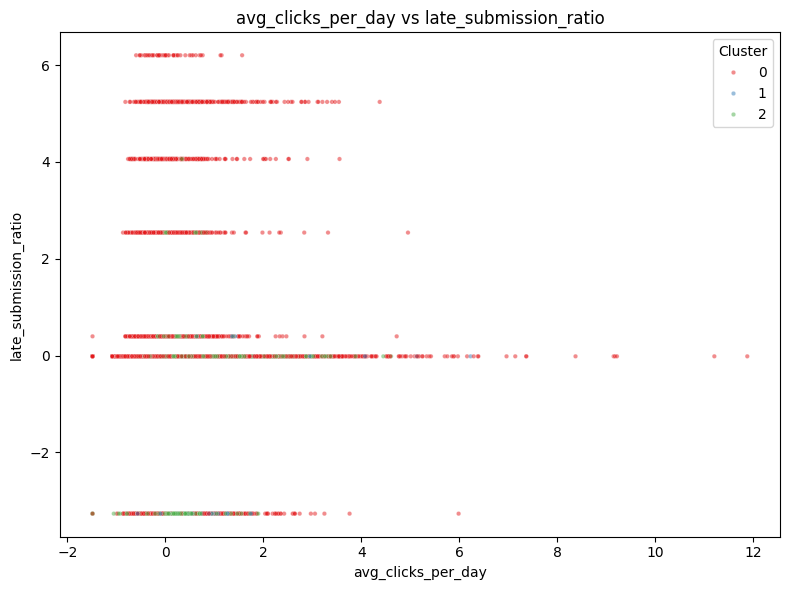

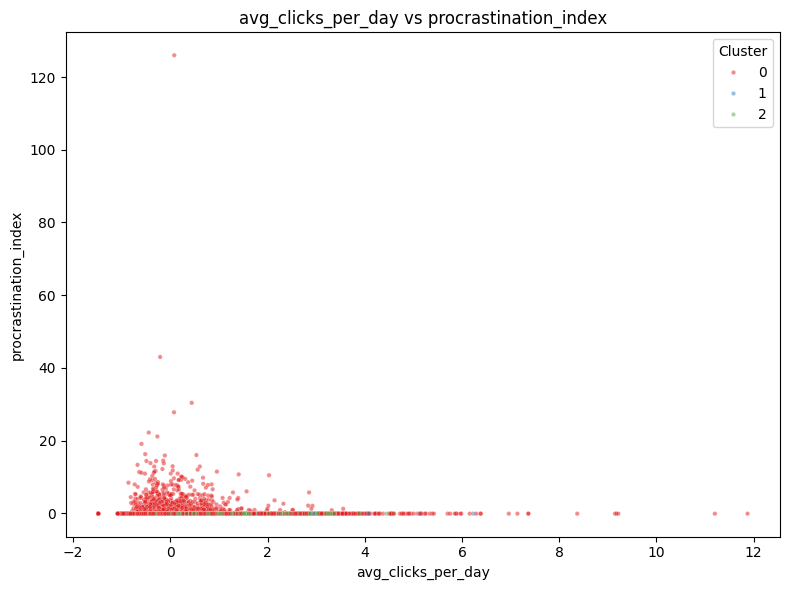

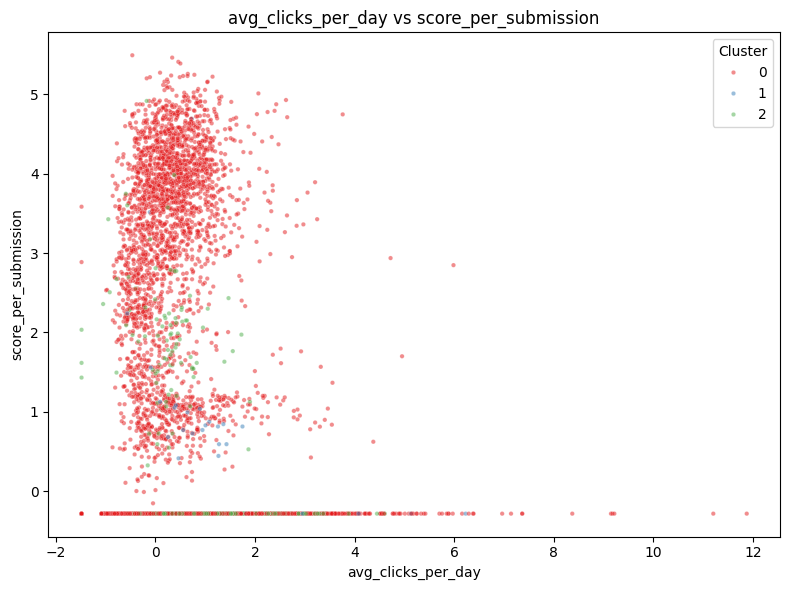

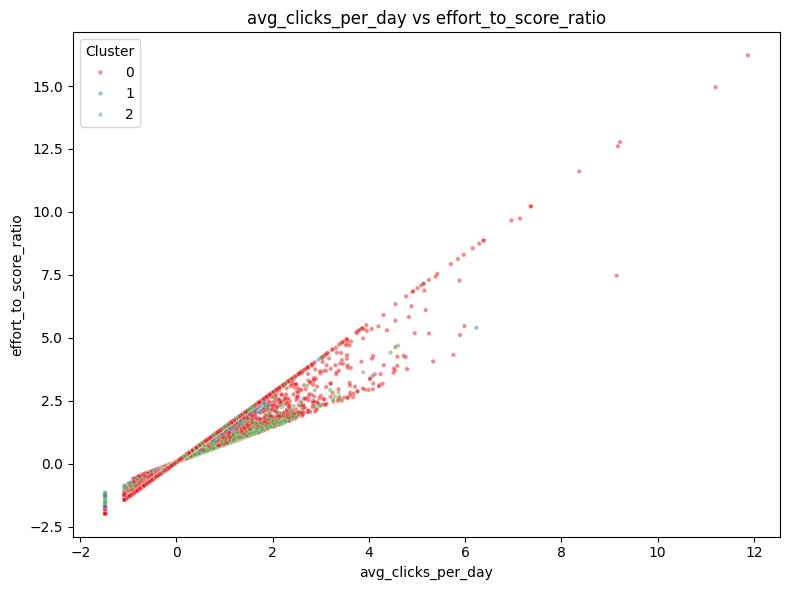

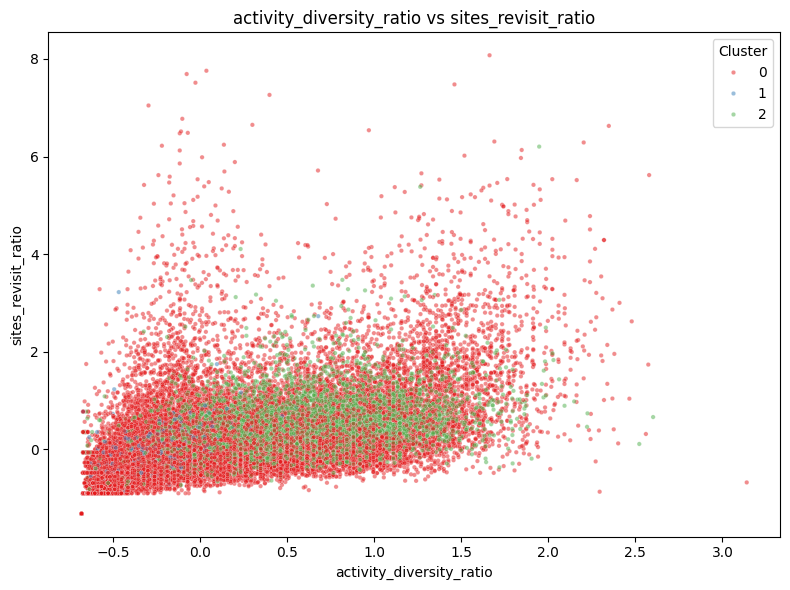

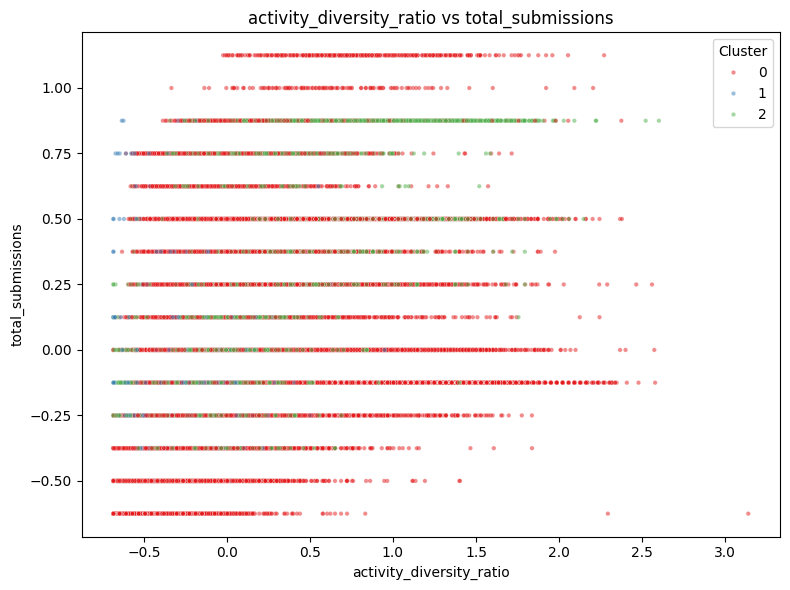

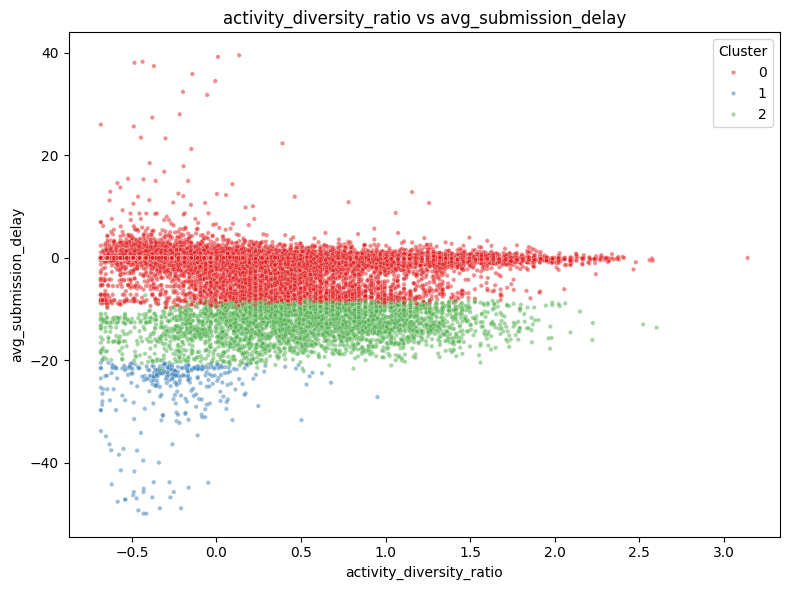

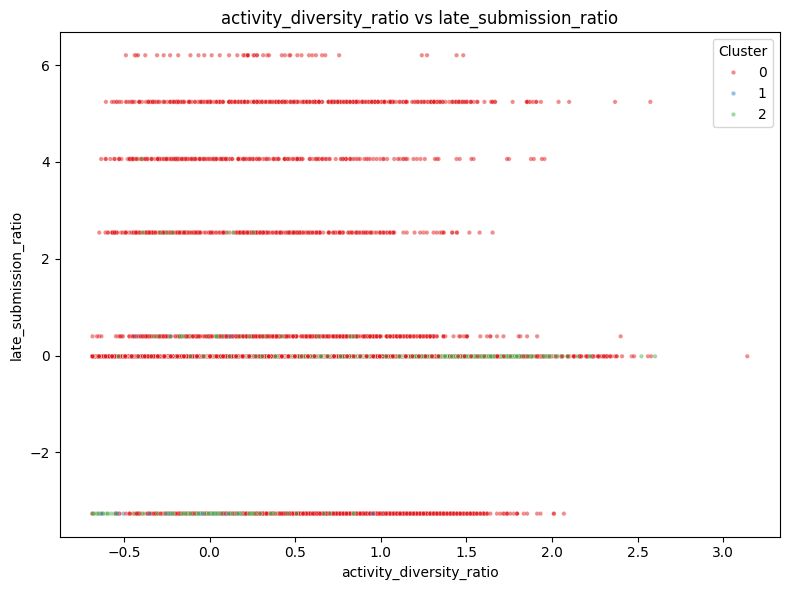

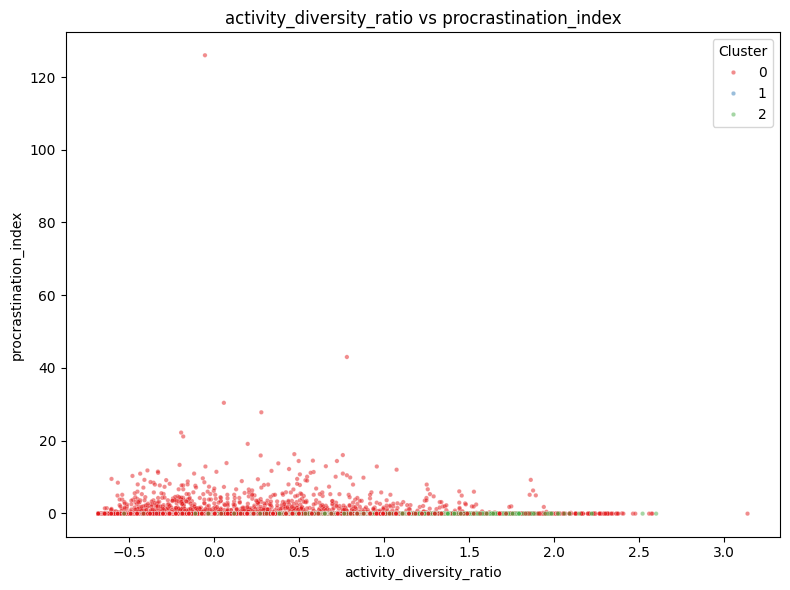

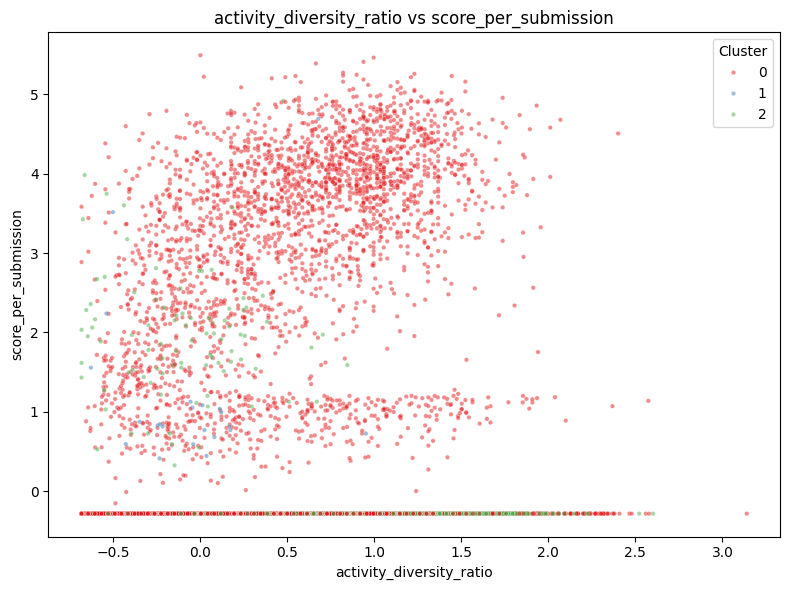

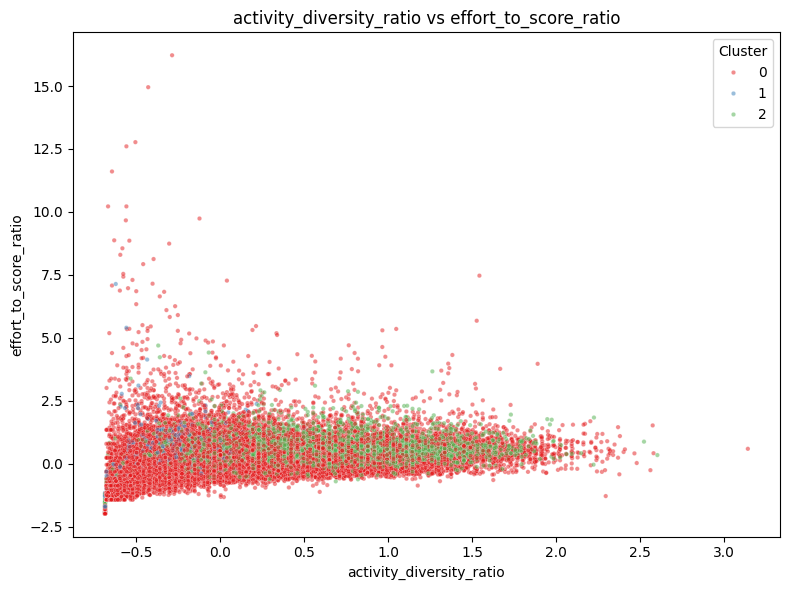

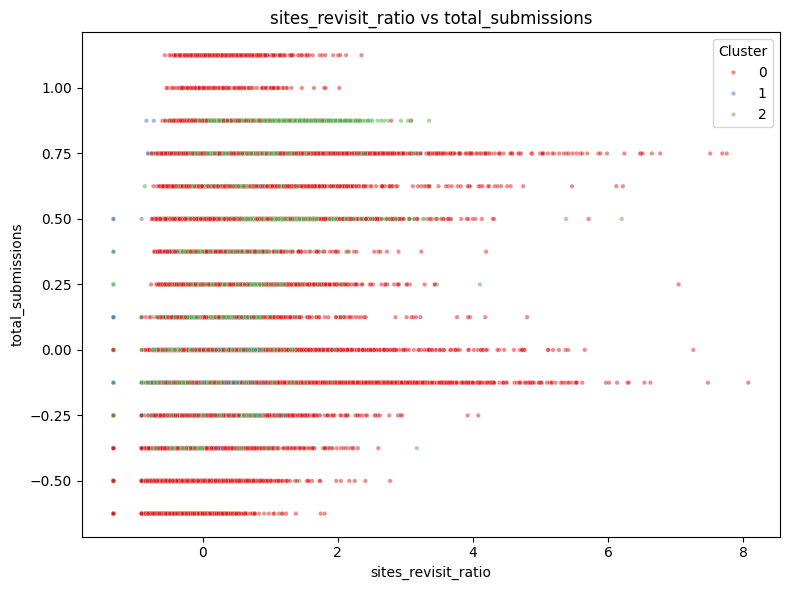

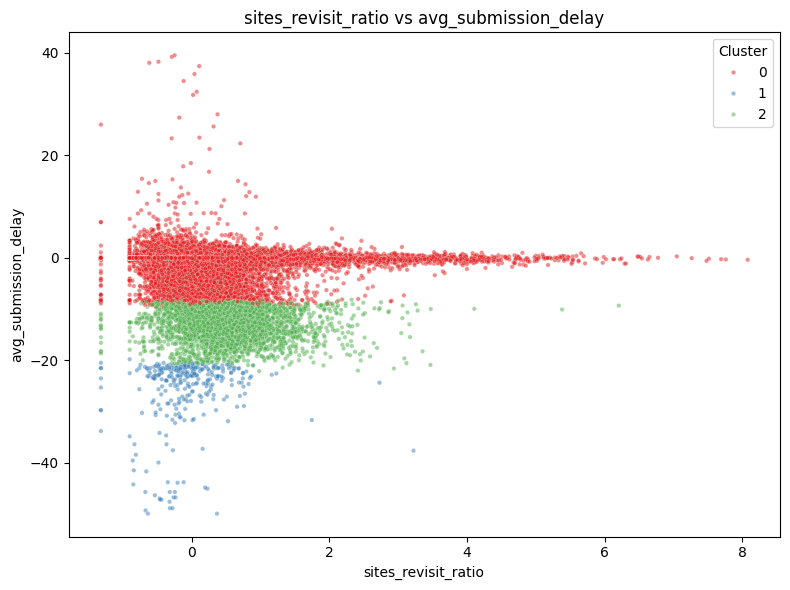

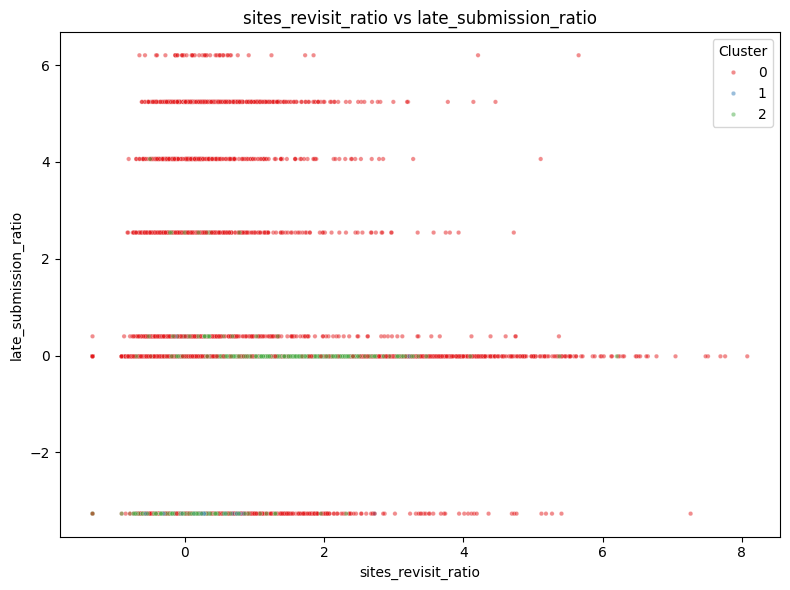

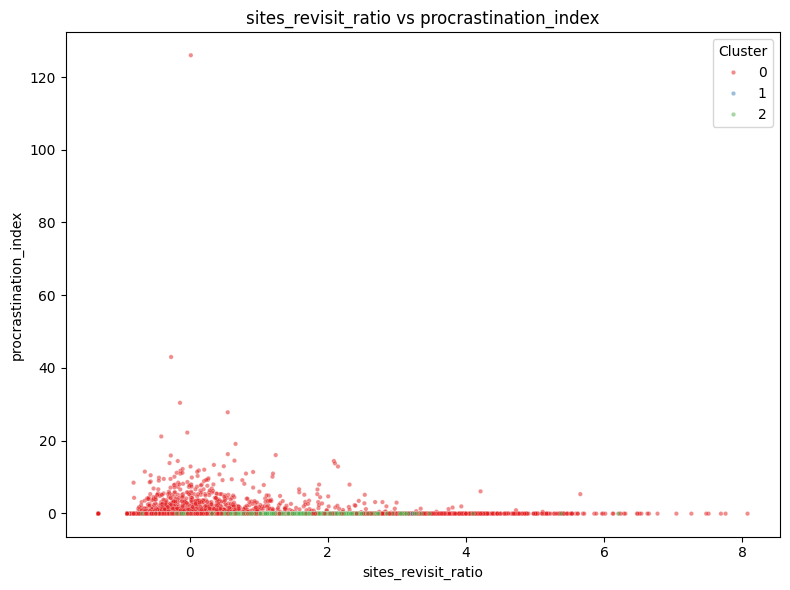

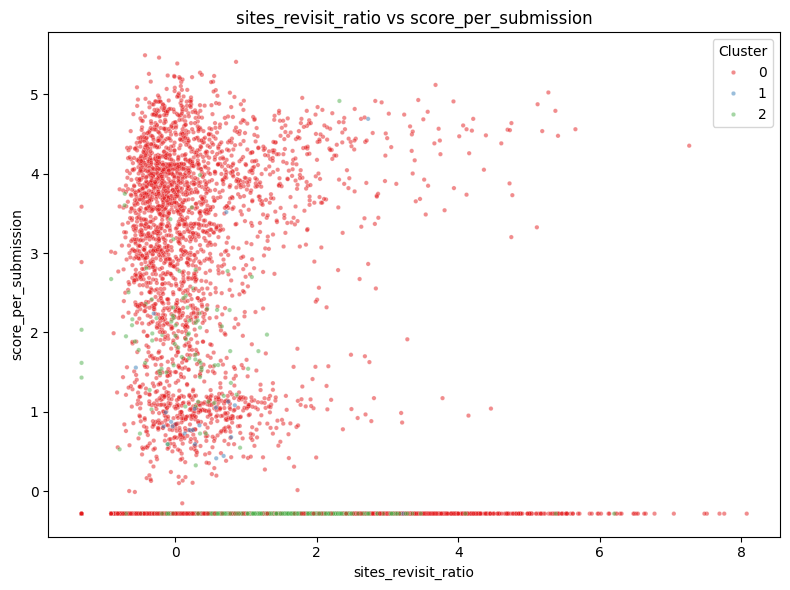

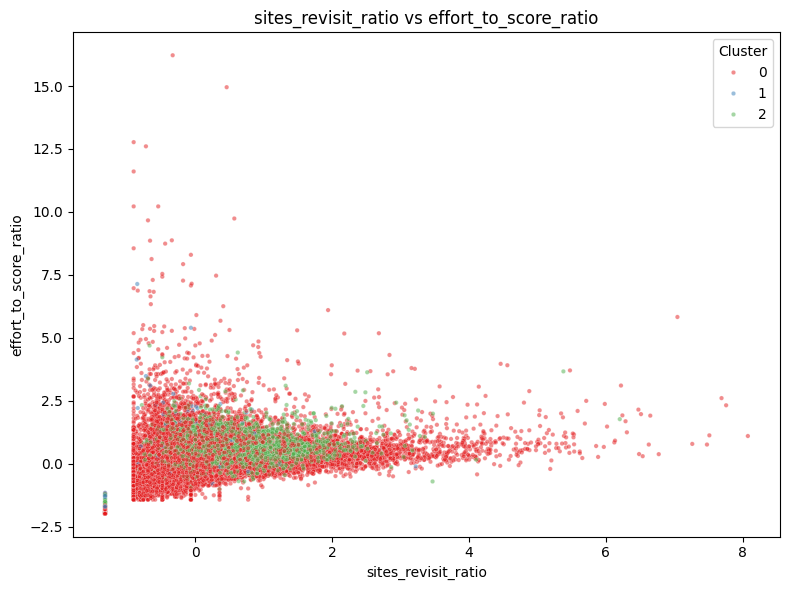

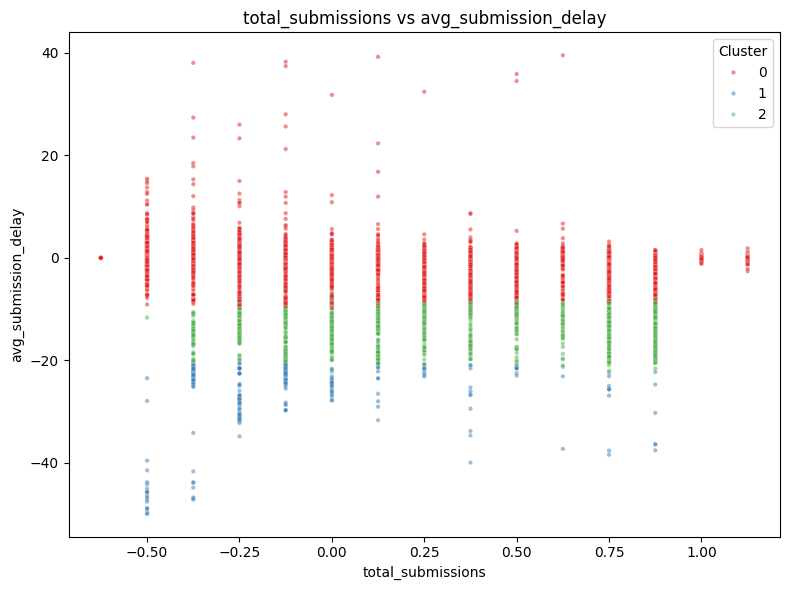

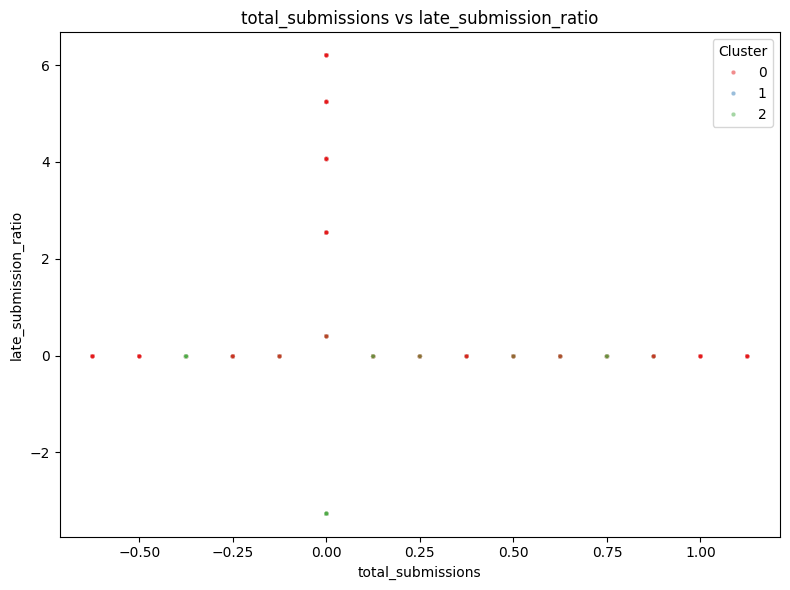

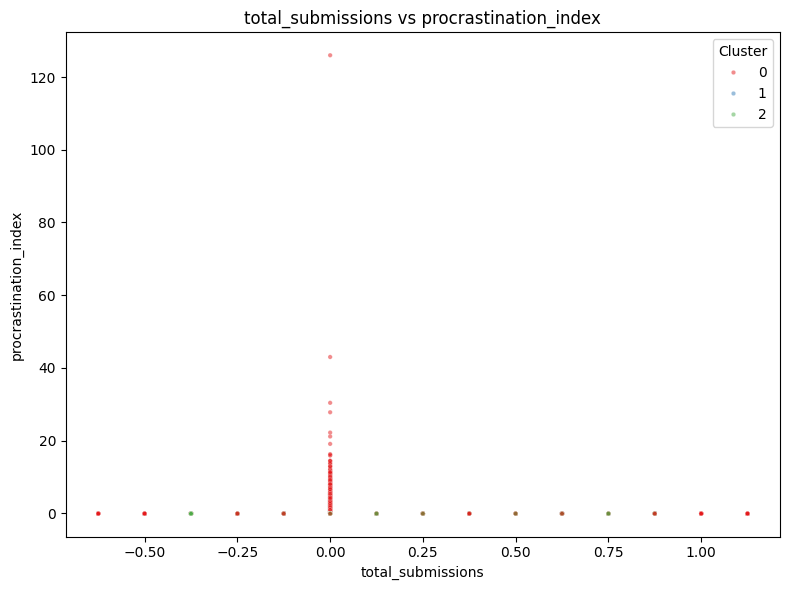

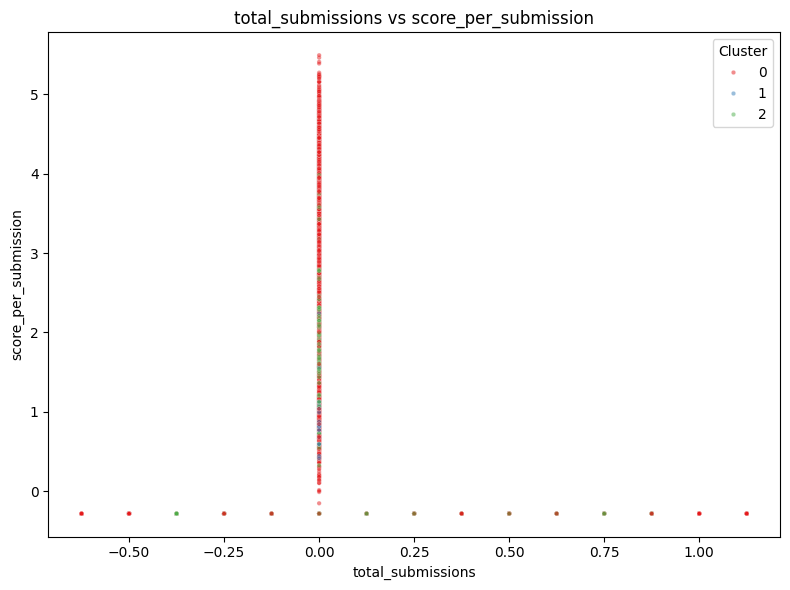

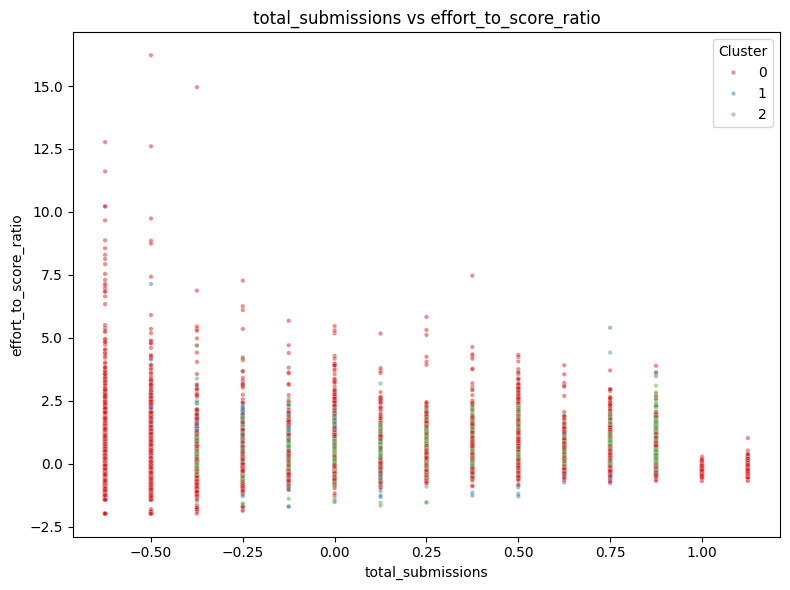

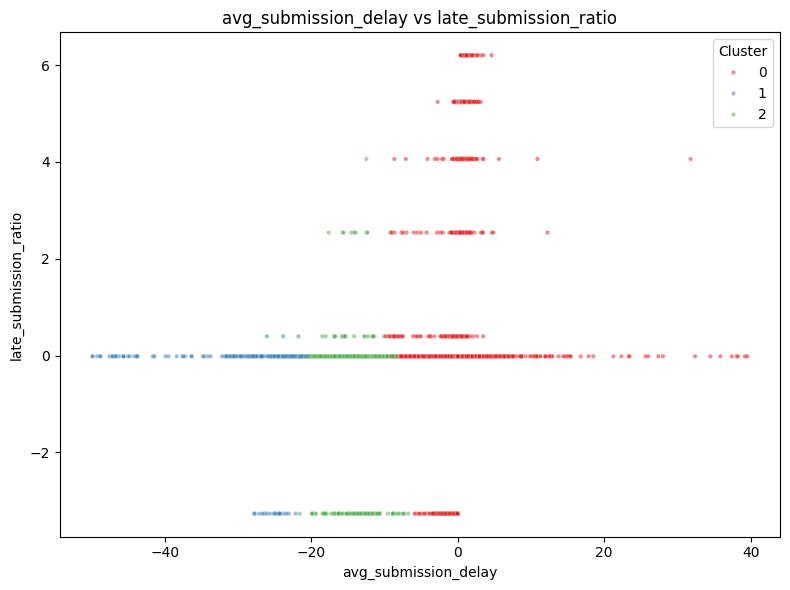

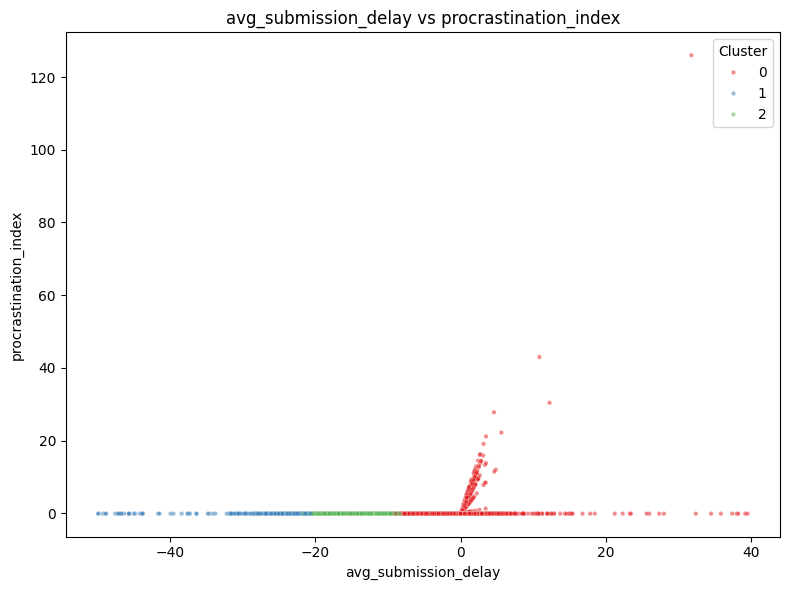

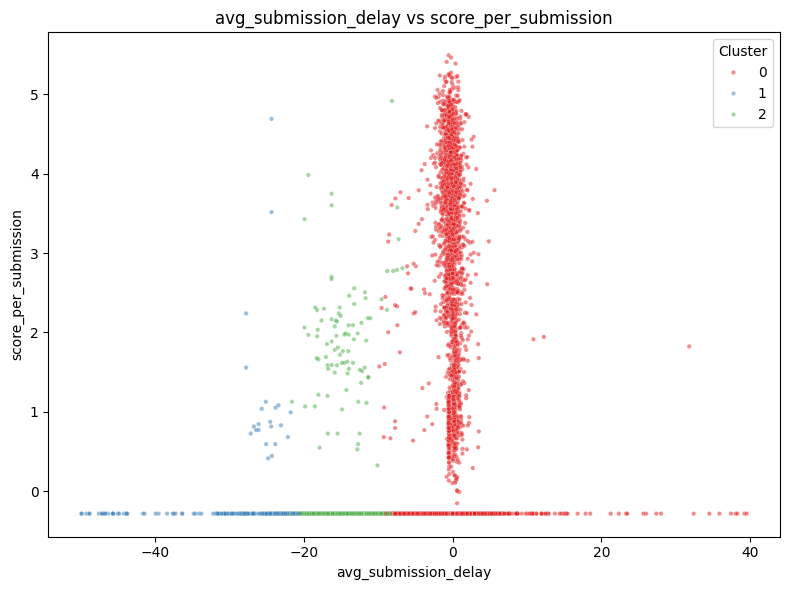

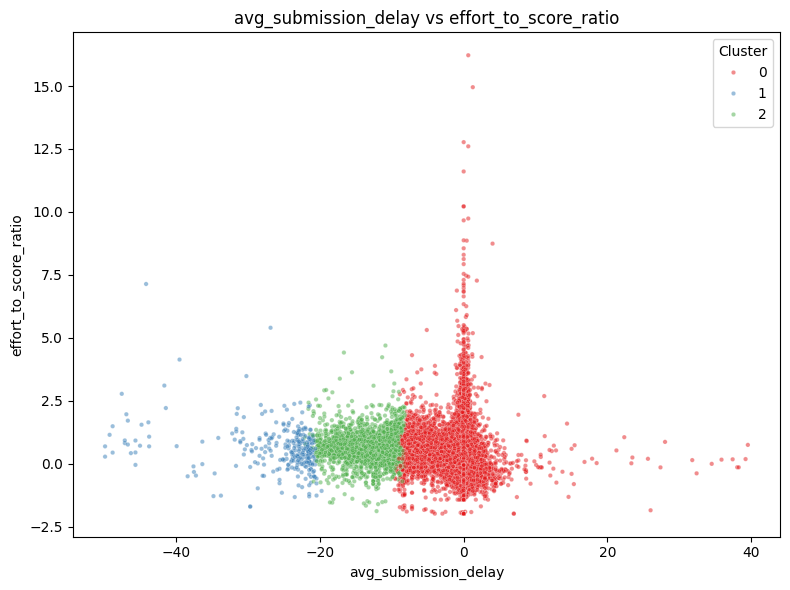

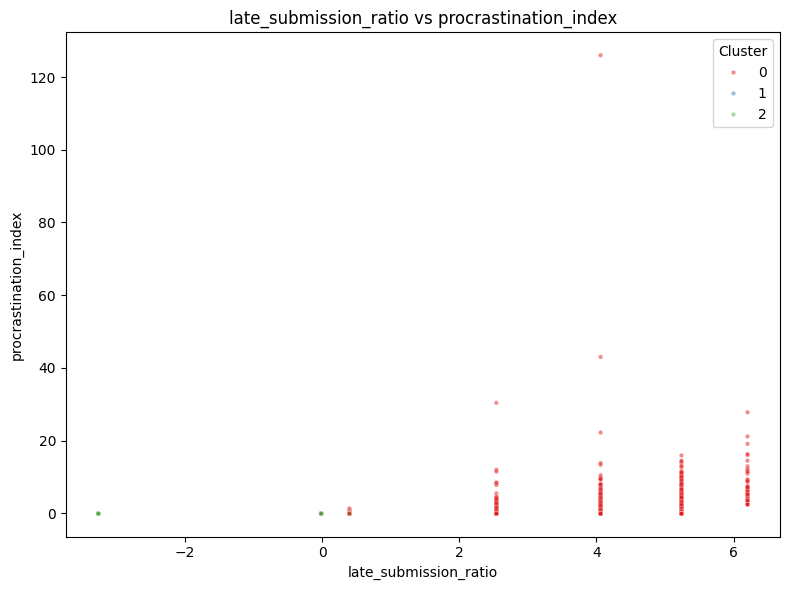

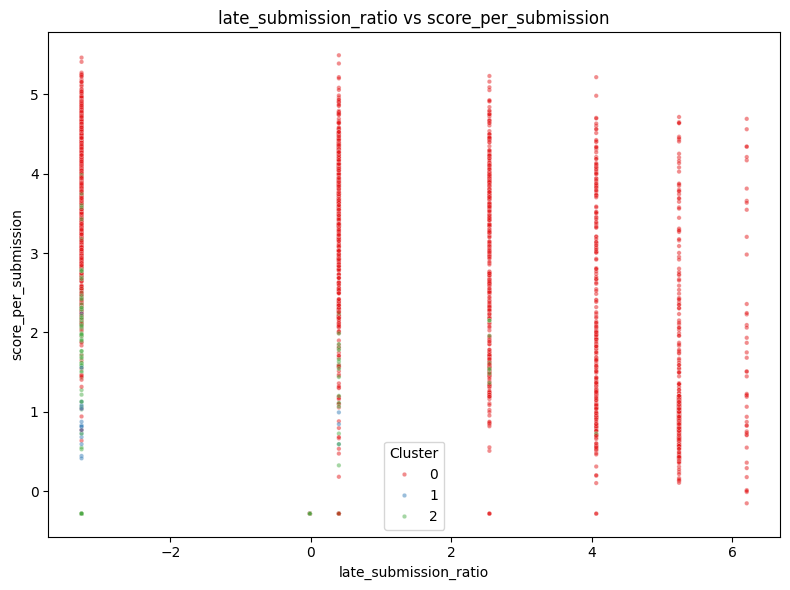

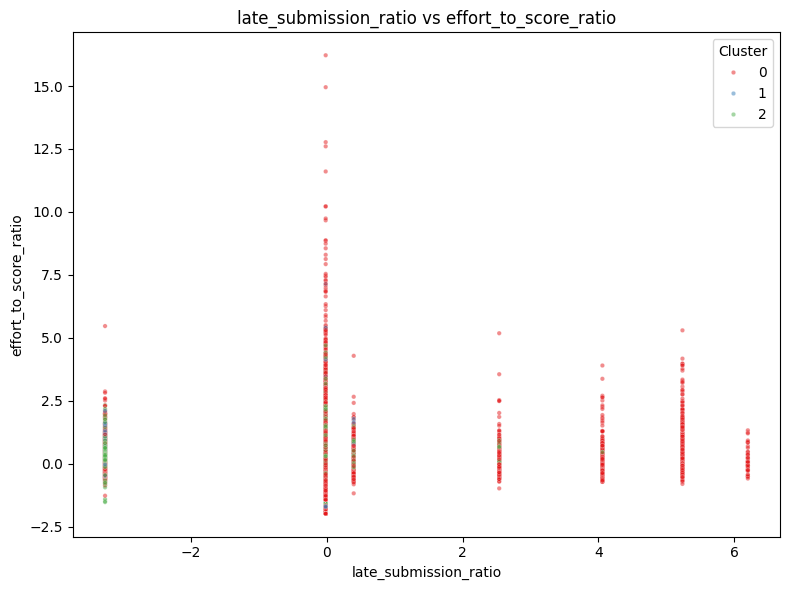

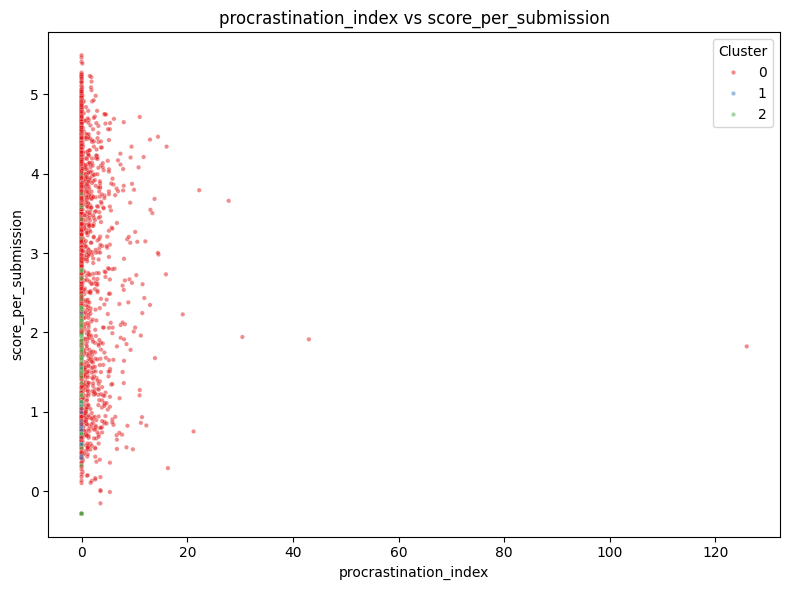

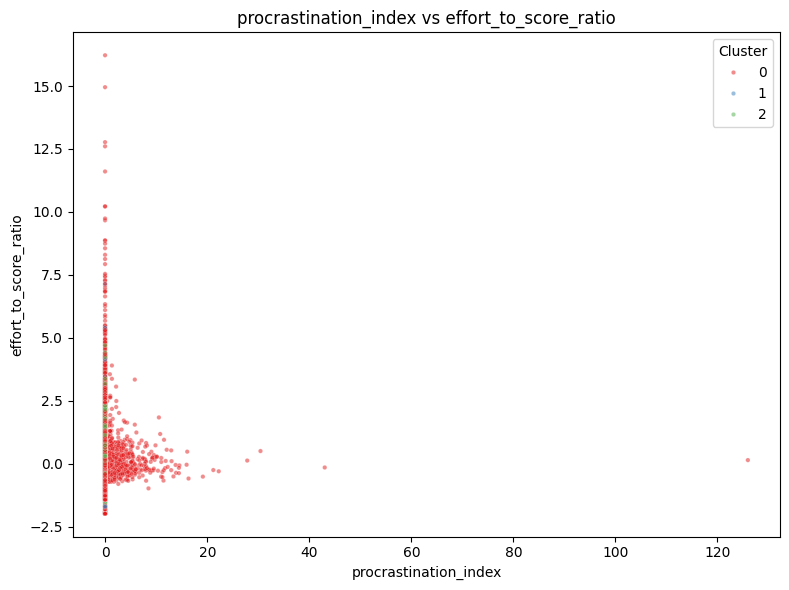

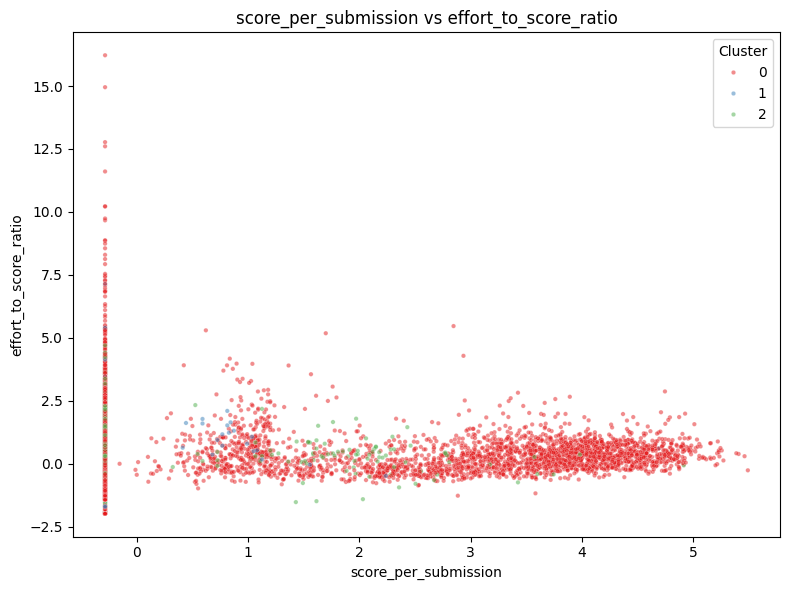

In [10]:
# Initialize and fit BIRCH
birch = Birch(
    threshold=0.5,
    branching_factor=50,
    n_clusters=3  # Let BIRCH determine optimal subclusters first
)

# Fit and predict
cluster_labels = birch.fit_predict(df)

# Add cluster labels to dataframe
df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

print(f"Number of clusters found: {len(np.unique(cluster_labels))}")
print(f"\nCluster distribution:")
print(df_clustered['cluster'].value_counts().sort_index())


# Reduce to 2D using PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# Plot clusters with discrete legend
plt.figure(figsize=(10, 8))

colors = ['green', 'blue', 'red']  # Match viridis-like colors
for cluster_id in np.unique(cluster_labels):
    mask = cluster_labels == cluster_id
    plt.scatter(df_pca[mask, 0], df_pca[mask, 1],
                c=colors[cluster_id], label=f'Cluster {cluster_id}',
                alpha=0.5, s=10)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('BIRCH Clustering Results (PCA Projection)')
plt.legend(title='Cluster', loc='best')
plt.tight_layout()
plt.show()

# Get PCA loadings (feature contributions to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=df.columns
)

# Sort by absolute contribution to PC1
loadings['PC1_abs'] = loadings['PC1'].abs()
loadings_sorted = loadings.sort_values('PC1_abs', ascending=False).drop('PC1_abs', axis=1)

print("PCA Loadings (Feature Contributions):")
print(loadings_sorted.round(3))

# Plot all 9 features for each PC
n_features = len(df.columns)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PC1 loadings
top_pc1 = loadings['PC1'].abs().nlargest(n_features).index
axes[0].barh(range(n_features), loadings.loc[top_pc1, 'PC1'])
axes[0].set_yticks(range(n_features))
axes[0].set_yticklabels(top_pc1)
axes[0].set_xlabel('Loading')
axes[0].set_title(f'Features for PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# PC2 loadings
top_pc2 = loadings['PC2'].abs().nlargest(n_features).index
axes[1].barh(range(n_features), loadings.loc[top_pc2, 'PC2'])
axes[1].set_yticks(range(n_features))
axes[1].set_yticklabels(top_pc2)
axes[1].set_xlabel('Loading')
axes[1].set_title(f'Features for PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# Use current 9 features for pairwise plots
features = df.columns.tolist()

# Generate all pairwise combinations
from itertools import combinations

for x_feat, y_feat in combinations(features, 2):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=x_feat, y=y_feat, data=df_clustered,
                    hue='cluster', palette='Set1', alpha=0.5, s=10)
    plt.xlabel(x_feat)
    plt.ylabel(y_feat)
    plt.title(f'{x_feat} vs {y_feat}')
    plt.legend(title='Cluster', loc='best')
    plt.tight_layout()
    plt.show()


Cluster Statistics:
   Cluster  Count  Avg_submission_delay  Avg_sites_revisit_ratio  \
0        0  28705             -0.471680                 0.047649   
1        1    306            -25.972121                -0.080344   
2        2   3537            -12.803138                 0.503706   

   Avg_late_submission_ratio  Avg_clicks_per_day  
0                   0.012343           -0.057302  
1                  -0.213273            0.441495  
2                  -0.081717            0.625456  


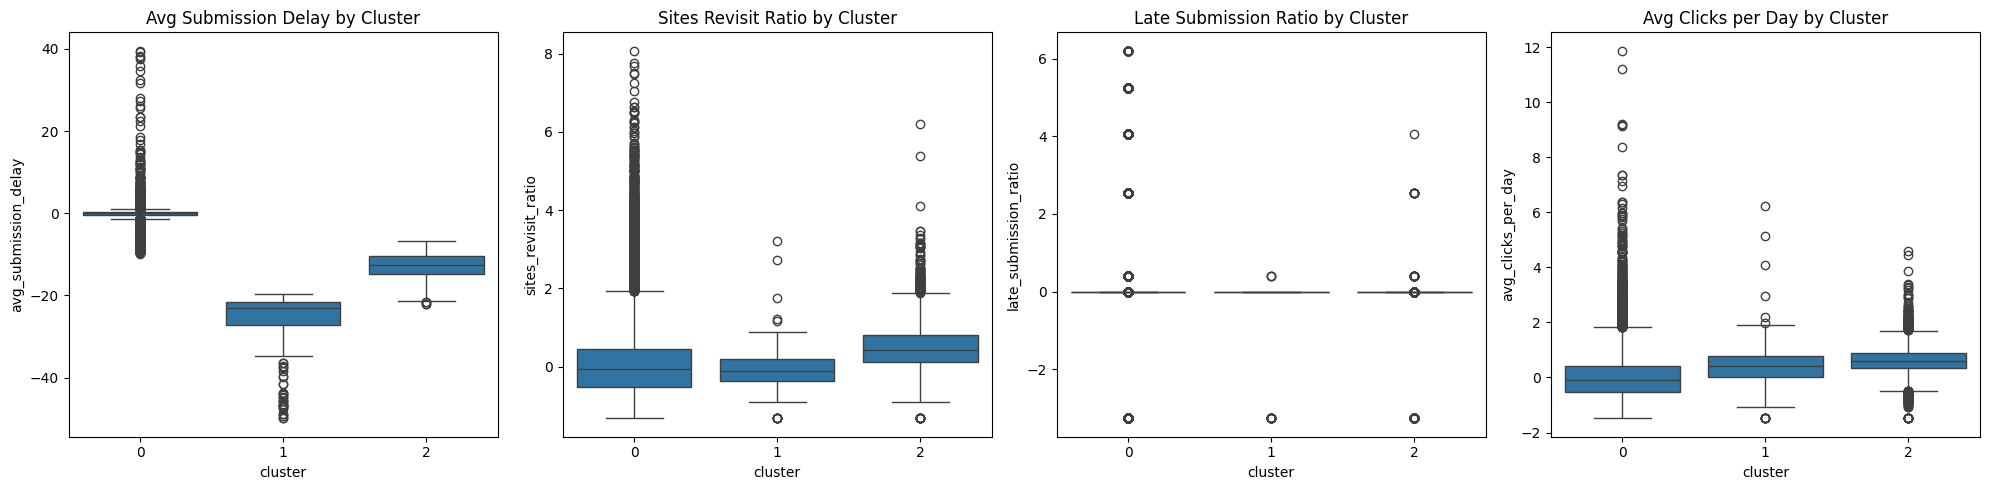

In [13]:
# Cluster statistics for top PCA features
print("\nCluster Statistics:")
cluster_stats = df_clustered.groupby('cluster').agg({
    'avg_submission_delay': ['count', 'mean'],
    'sites_revisit_ratio': 'mean',
    'late_submission_ratio': 'mean',
    'avg_clicks_per_day': 'mean'
}).reset_index()

cluster_stats.columns = ['Cluster', 'Count', 'Avg_submission_delay', 
                         'Avg_sites_revisit_ratio', 'Avg_late_submission_ratio', 
                         'Avg_clicks_per_day']
print(cluster_stats)

# Boxplots for top PCA features
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.boxplot(x='cluster', y='avg_submission_delay', data=df_clustered, ax=axes[0])
axes[0].set_title('Avg Submission Delay by Cluster')

sns.boxplot(x='cluster', y='sites_revisit_ratio', data=df_clustered, ax=axes[1])
axes[1].set_title('Sites Revisit Ratio by Cluster')

sns.boxplot(x='cluster', y='late_submission_ratio', data=df_clustered, ax=axes[2])
axes[2].set_title('Late Submission Ratio by Cluster')

sns.boxplot(x='cluster', y='avg_clicks_per_day', data=df_clustered, ax=axes[3])
axes[3].set_title('Avg Clicks per Day by Cluster')

plt.tight_layout()
plt.show()

## 3. Cluster Evaluation

Evaluate clustering quality using:
- **Silhouette Score**: Measures how similar points are to their own cluster vs other clusters (-1 to 1, higher is better)
- **Calinski-Harabasz Index**: Ratio of between-cluster to within-cluster variance (higher is better)
- **Davies-Bouldin Index**: Average similarity between clusters (lower is better)


In [14]:
# Calculate evaluation metrics
silhouette = silhouette_score(df, cluster_labels)
calinski = calinski_harabasz_score(df, cluster_labels)
davies = davies_bouldin_score(df, cluster_labels)

print("=" * 50)
print("CLUSTERING EVALUATION METRICS")
print("=" * 50)
print(f"\nSilhouette Score:        {silhouette:.4f}")
print(f"Calinski-Harabasz Index: {calinski:.4f}")
print(f"Davies-Bouldin Index:    {davies:.4f}")


CLUSTERING EVALUATION METRICS

Silhouette Score:        0.6695
Calinski-Harabasz Index: 28787.9486
Davies-Bouldin Index:    0.5553


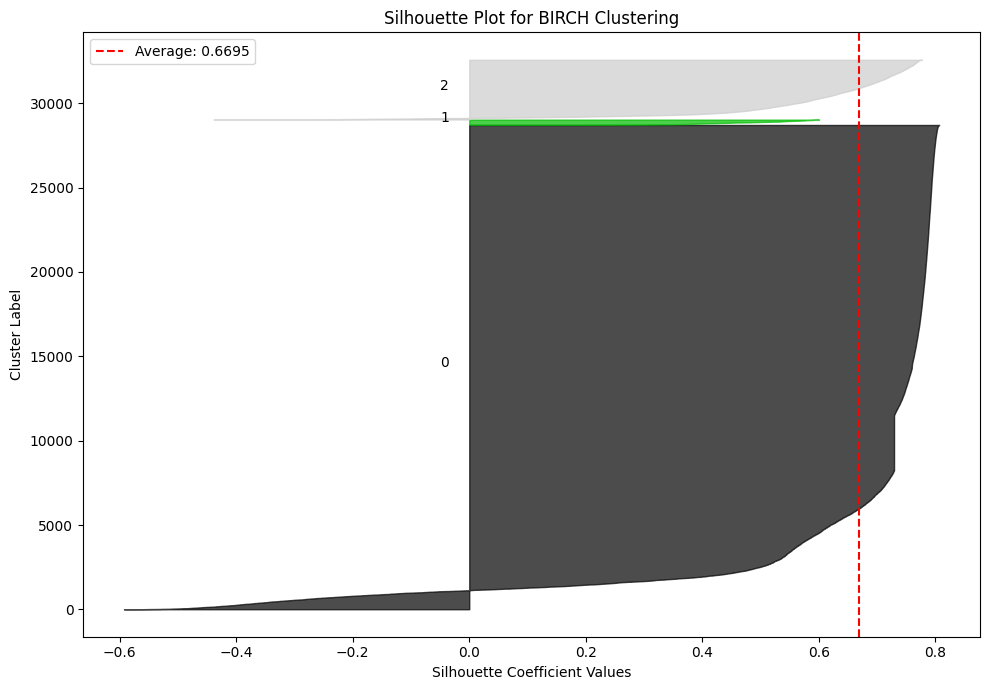

In [15]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

# Calculate silhouette scores
silhouette_avg = silhouette_score(df, cluster_labels)
sample_silhouette_values = silhouette_samples(df, cluster_labels)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

y_lower = 10
n_clusters = len(np.unique(cluster_labels))
colors = cm.nipy_spectral(np.linspace(0, 1, n_clusters))

for i in range(n_clusters):
    cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    cluster_silhouette_values.sort()
    
    size_cluster_i = cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_values,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax.set_title('Silhouette Plot for BIRCH Clustering')
ax.set_xlabel('Silhouette Coefficient Values')
ax.set_ylabel('Cluster Label')
ax.axvline(x=silhouette_avg, color='red', linestyle='--', label=f'Average: {silhouette_avg:.4f}')
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## 5. Cluster Profiling

Analyze the characteristics of each cluster by examining feature means.


In [16]:
# Calculate cluster statistics
cluster_stats = df_clustered.groupby('cluster').mean()

print("=" * 50)
print("CLUSTER PROFILES (Feature Means)")
print("=" * 50)
print(f"\nNumber of samples per cluster:")
print(df_clustered['cluster'].value_counts().sort_index())
print(f"\n")
cluster_stats.T


CLUSTER PROFILES (Feature Means)

Number of samples per cluster:
cluster
0    28705
1      306
2     3537
Name: count, dtype: int64




cluster,0,1,2
avg_clicks_per_day,-0.057302,0.441495,0.625456
activity_diversity_ratio,0.083775,-0.242676,0.543303
sites_revisit_ratio,0.047649,-0.080344,0.503706
total_submissions,-0.024813,-0.121324,0.606446
avg_submission_delay,-0.471680,-25.972121,-12.803138
late_submission_ratio,0.012343,-0.213273,-0.081717
procrastination_index,0.009787,-0.073103,-0.073103
score_per_submission,0.029825,-0.176564,-0.226773
effort_to_score_ratio,-0.083550,0.613871,0.624950


# Further analysis

Outcome Counts per Cluster:
final_result  Distinction  Fail   Pass  Withdrawn
cluster                                          
0                    2293  6404  10379       9629
1                       3   132     17        154
2                     728   511   1964        334

Outcome Rates (%) per Cluster:
final_result  Distinction   Fail   Pass  Withdrawn
cluster                                           
0                    7.99  22.31  36.16      33.54
1                    0.98  43.14   5.56      50.33
2                   20.58  14.45  55.53       9.44


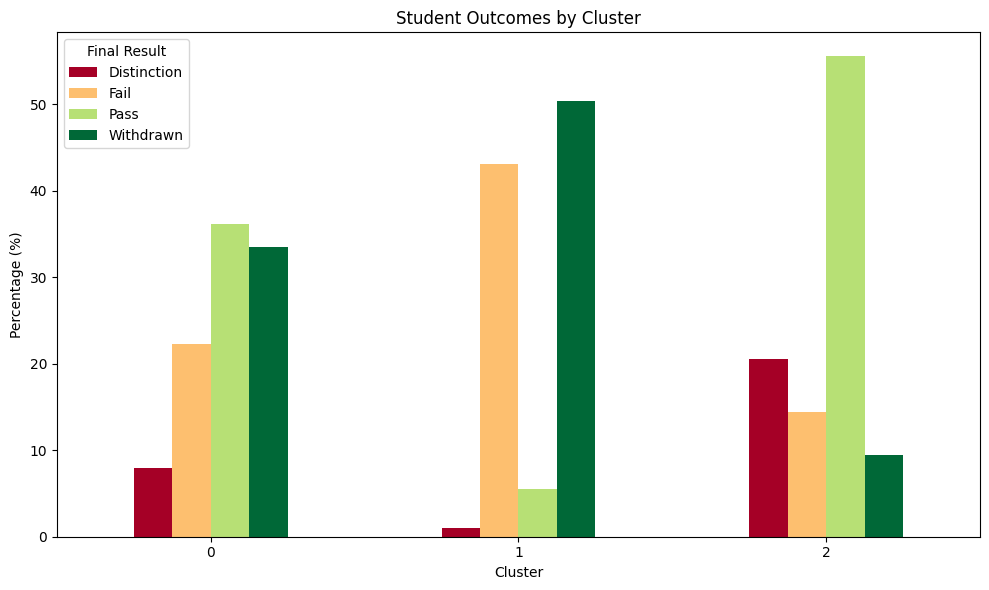


Cluster 0:
  Total students: 28705
  Distinction: 8.0%
  Fail: 22.3%
  Pass: 36.2%
  Withdrawn: 33.5%

Cluster 1:
  Total students: 306
  Distinction: 1.0%
  Fail: 43.1%
  Pass: 5.6%
  Withdrawn: 50.3%

Cluster 2:
  Total students: 3537
  Distinction: 20.6%
  Fail: 14.4%
  Pass: 55.5%
  Withdrawn: 9.4%
Simplified Outcome Counts per Cluster:
outcome_simplified  Pass and Distinction  Fail  Withdrawn
cluster                                                  
0                                  12672  6404       9629
1                                     20   132        154
2                                   2692   511        334

Simplified Outcome Rates (%) per Cluster:
outcome_simplified  Pass and Distinction   Fail  Withdrawn
cluster                                                   
0                                  44.15  22.31      33.54
1                                   6.54  43.14      50.33
2                                  76.11  14.45       9.44


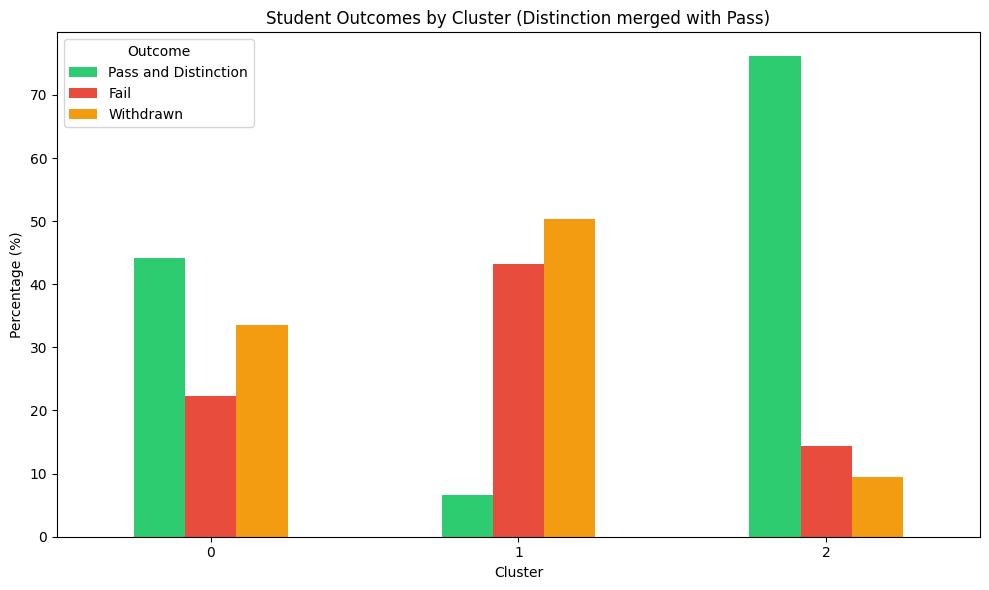


Cluster 0 (n=28705):
  Pass and Distinction: 44.1%
  Fail: 22.3%
  Withdrawn: 33.5%

Cluster 1 (n=306):
  Pass and Distinction: 6.5%
  Fail: 43.1%
  Withdrawn: 50.3%

Cluster 2 (n=3537):
  Pass and Distinction: 76.1%
  Fail: 14.4%
  Withdrawn: 9.4%


In [19]:
# Load original data with final_result
original_df = pd.read_csv('../data/merged/merged_1.csv')

# Add cluster labels to original data
original_df['cluster'] = cluster_labels

# Cross-tabulation: cluster vs final_result
outcome_counts = pd.crosstab(original_df['cluster'], original_df['final_result'])
outcome_rates = pd.crosstab(original_df['cluster'], original_df['final_result'], normalize='index') * 100

print("Outcome Counts per Cluster:")
print(outcome_counts)
print("\nOutcome Rates (%) per Cluster:")
print(outcome_rates.round(2))

# Plot outcome rates
outcome_rates.plot(kind='bar', figsize=(10, 6), colormap='RdYlGn')
plt.title('Student Outcomes by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.legend(title='Final Result')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Summary
for cluster in sorted(original_df['cluster'].unique()):
    print(f"\nCluster {cluster}:")
    print(f"  Total students: {len(original_df[original_df['cluster'] == cluster])}")
    for outcome in outcome_rates.columns:
        rate = outcome_rates.loc[cluster, outcome]
        print(f"  {outcome}: {rate:.1f}%")




# Create simplified outcome (merge Distinction + Pass)
original_df['outcome_simplified'] = original_df['final_result'].replace({
    'Distinction': 'Pass and Distinction',
    'Pass': 'Pass and Distinction',
    'Fail': 'Fail',
    'Withdrawn': 'Withdrawn'
})

# Cross-tabulation with simplified outcomes
outcome_counts_simple = pd.crosstab(original_df['cluster'], original_df['outcome_simplified'])
outcome_rates_simple = pd.crosstab(original_df['cluster'], original_df['outcome_simplified'], normalize='index') * 100

# Reorder columns
col_order = ['Pass and Distinction', 'Fail', 'Withdrawn']
outcome_counts_simple = outcome_counts_simple[col_order]
outcome_rates_simple = outcome_rates_simple[col_order]

print("Simplified Outcome Counts per Cluster:")
print(outcome_counts_simple)
print("\nSimplified Outcome Rates (%) per Cluster:")
print(outcome_rates_simple.round(2))

# Plot simplified outcome rates
colors = ['#2ecc71', '#e74c3c', '#f39c12']  # Green, Red, Orange
outcome_rates_simple.plot(kind='bar', figsize=(10, 6), color=colors)
plt.title('Student Outcomes by Cluster (Distinction merged with Pass)')
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.legend(title='Outcome')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Summary
for cluster in sorted(original_df['cluster'].unique()):
    print(f"\nCluster {cluster} (n={len(original_df[original_df['cluster'] == cluster])}):")
    for outcome in col_order:
        rate = outcome_rates_simple.loc[cluster, outcome]
        print(f"  {outcome}: {rate:.1f}%")

